In [1]:
# Made originally by Fernando Vizeu at https://github.com/giecaruff/PasseyTOCMethod
# Adapted on GIECAR
from stoneforge.reservoir.toc_v import TOCProcessor
from stoneforge.vis.plot_welllog import LogPlot

In [2]:
mnemonics = {
    "depth": "DEPTH",
    "dt": "DT",
    "logrt": "RT90",
    "gr": "GR",
    "cali": "CAL",
    "toc": "TOC",
}

processor = TOCProcessor(
    csv_path=r"synth_toc_1300_3000_2.csv",
    las_path=r"C:\Users\mario\Documents\massape\7-MP-56D-BA.las",
    mnemonics=mnemonics,
    cot_position=3,
    cot_depth_position=1,
    lom=10.0,
    dt_baseline=75.0,
    logrt_baseline=0.3,
    skip=(1)
)

result = processor.run()

Figure size (depths and scales detected): 11.69 x 7.09 polegadas
Displaying figure... depth range:{self.range}


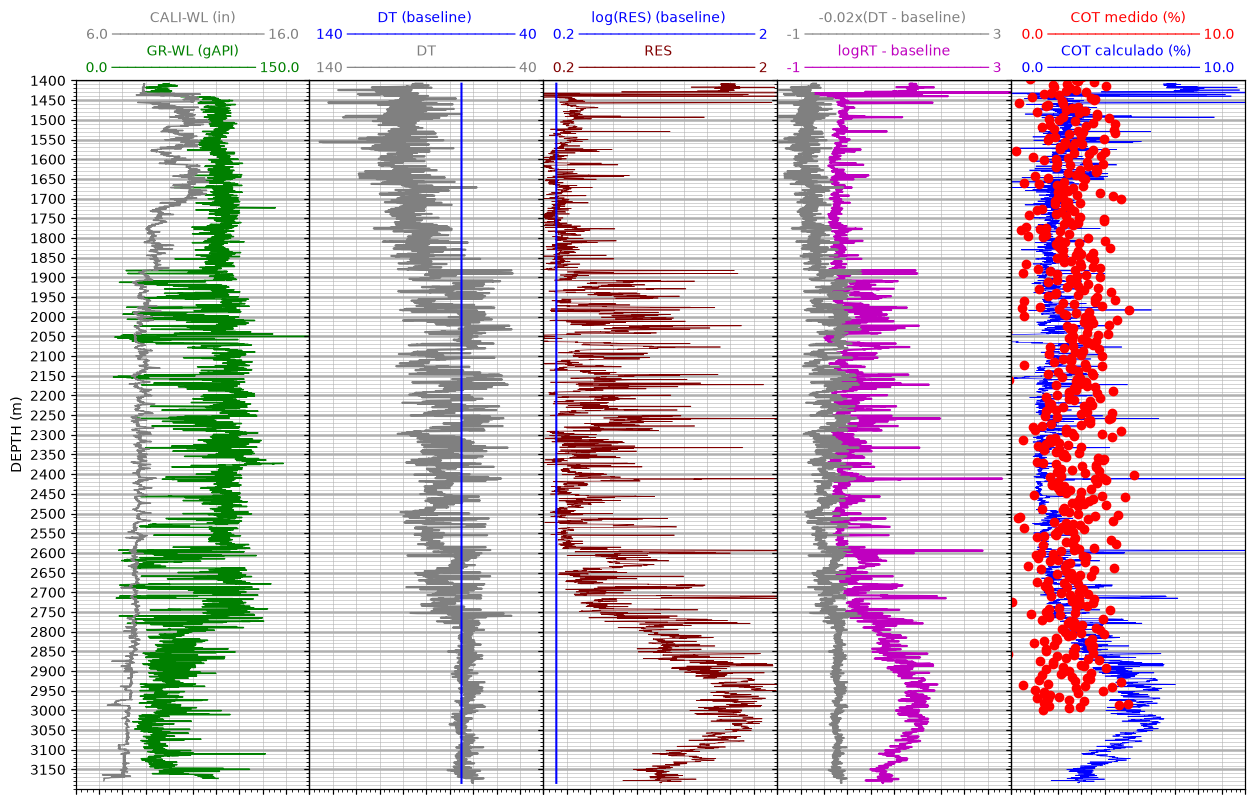

In [3]:
%matplotlib inline
img = LogPlot(res = 10000,size=(29.7, 30.0),top=1400, bot=3200, title=("",1.12)) # 5400

img.set_depth(result['depth'], d="DEPTH (m)")
img.normal_plot(x=result['gr'],c='green',grid=1, lw=1., vmin=0., vmax=150., label='GR-WL (gAPI)')
img.normal_plot(x=result['cali'],c='grey',lw=1., vmin=6., vmax=16., label='CALI-WL (in)', track=True)

img.set_depth(result['depth'])
img.normal_plot(x = result['dt'],c='grey', grid=1, vmin=140, vmax=40, label='DT',lw=1.5)
img.normal_plot(x = result['dt_baseline'],c='blue', grid=1, vmin=140, vmax=40, label='DT (baseline)',lw=1.5, track=True)

img.set_depth(result['depth'])
img.normal_plot(x=result['logrt'],c='maroon', vmin=0.2, vmax=2, label='RES')
img.normal_plot(x = result['rt_baseline'],c='blue', grid=1, vmin=0.2, vmax=2, label='log(RES) (baseline)',lw=1.5, track=True)

img.set_depth(result['depth'])
img.normal_plot(x = result["logrt_minus_baseline"],c='m',grid=1,vmin=-1, vmax=3, label='logRT - baseline',lw=1.5)
img.normal_plot(x = result["dt_minus_baseline_scaled"],c='grey',grid=1, vmin=-1, vmax=3, label='-0.02x(DT - baseline)',lw=1.5, track=True)

img.set_depth(result['depth'])
img.normal_plot(x=result['calculated_cot_pct'],c='b', grid = 1, vmin=0., vmax=10., label='COT calculado (%)')
img.set_depth(result["measured_cot_depth"])
img.normal_plot(x=result["measured_cot_pct"],c='r', s="", m='o', grid = 1, vmin=0., vmax=10., label='COT medido (%)', track=True)

img.show()